In [208]:
import pandas as pd
df = pd.read_csv('Combined_SSkitchen_Cleaned.csv')

/tmp/ipykernel_4977/3319847471.py:2: DtypeWarning: Columns (9,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Combined_SSkitchen_Cleaned.csv')


In [206]:
df.columns

Index(['date', 'device_id', 'activity_1', 'type_1', 'activity_2', 'type_2',
       'timestamp', 'data_temperature', 'data_humidity', 'data_pressure',
       'data_pm1', 'data_pm2_5', 'data_pm10', 'data_co', 'data_voc',
       'data_co2'],
      dtype='object')

In [211]:
import pandas as pd
import numpy as np

# 1. Specify the format to handle AM/PM (%I is 12-hour clock, %p is AM/PM)
# Adjust the format string below if your date uses slashes (/) instead of dashes (-)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%I:%M:%S %p')

# 2. Create 'hour' column (This will now naturally be 0-23)
df['hour'] = df['timestamp'].dt.hour

# 3. Create 'minute' column
df['minute'] = df['timestamp'].dt.minute

# 4. Create 'day' column: 1 if hour is PM (12 to 23), otherwise 0
conditions = [
    df['hour'] <= 6,                           # 1. 12:00 AM to 6:59 AM (Early Morning/Night)
    (df['hour'] > 6) & (df['hour'] <= 12),     # 2. 7:00 AM to 12:59 PM (Morning/Noon)
    (df['hour'] > 12) & (df['hour'] <= 18),    # 3. 1:00 PM to 6:59 PM (Afternoon/Evening)
    (df['hour'] > 18) & (df['hour'] <= 23)     # 4. 7:00 PM to 11:59 PM (Night)
]

# Define the outputs matching each condition above
choices = [0, 1, 2, 3]

# Apply conditions
df['day'] = np.select(conditions, choices, default=1)

In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39211 entries, 0 to 39210
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              39211 non-null  object        
 1   device_id         39211 non-null  int64         
 2   activity_1        3176 non-null   object        
 3   type_1            3210 non-null   object        
 4   activity_2        2583 non-null   object        
 5   type_2            2589 non-null   object        
 6   timestamp         39211 non-null  datetime64[ns]
 7   data_temperature  39211 non-null  float64       
 8   data_humidity     39211 non-null  float64       
 9   data_pressure     39211 non-null  object        
 10  data_pm1          39211 non-null  int64         
 11  data_pm2_5        39211 non-null  object        
 12  data_pm10         39211 non-null  int64         
 13  data_co           39211 non-null  float64       
 14  data_voc          3921

In [213]:
New_df = df.drop(columns=['date', 'device_id', 'activity_1', 'type_1', 'activity_2', 'type_2','timestamp','data_pressure','data_pm1','data_pm10','data_co' ])
New_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39211 entries, 0 to 39210
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_temperature  39211 non-null  float64
 1   data_humidity     39211 non-null  float64
 2   data_pm2_5        39211 non-null  object 
 3   data_voc          39211 non-null  float64
 4   data_co2          39211 non-null  int64  
 5   hour              39211 non-null  int32  
 6   minute            39211 non-null  int32  
 7   day               39211 non-null  int64  
dtypes: float64(3), int32(2), int64(2), object(1)
memory usage: 2.1+ MB


In [214]:
New_df['data_pm2_5']=New_df['data_pm2_5'].astype(str).str.replace(',','',regex= False)
New_df['data_pm2_5']=New_df['data_pm2_5'].astype(float)

In [216]:
# AQI class for VOC

def voc_to_aqi_class(voc):

    if voc <= 0.35:
        return 1

    elif voc <= 0.66:
        return 2

    elif voc <= 1.43:
        return 3

    elif voc <= 2.2:
        return 4

    elif voc <= 3.3:
        return 5

    else:
        return 6


# AQI class for CO2

def co2_to_aqi_class(co2):

    if co2 <= 450:
        return 1

    elif co2 <= 1000:
        return 2

    elif co2 <= 1500:
        return 3

    elif co2 <= 2500:
        return 4

    elif co2 <= 5000:
        return 5

    else:
        return 6

# AQI class for PM2_5

def pm2_5_to_aqi_class(pm2_5):

    if pm2_5 <= 30:
        return 1

    elif pm2_5 <= 60:
        return 2

    elif pm2_5 <= 90:
        return 3

    elif pm2_5 <= 120:
        return 4

    elif pm2_5 <= 250:
        return 5

    else:
        return 6

In [217]:
import pandas as pd

def add_aqi_attributes(df, voc_col, co2_col, pm2_5_col):
    """
    Reads the data_voc and data_co2 columns from the dataframe
    and appends the respective AQI class columns.
    """
    # Apply the conversion functions to the specific columns
    New_df['voc_Aqi'] = df[voc_col].apply(voc_to_aqi_class)
    New_df['co2_Aqi'] = df[co2_col].apply(co2_to_aqi_class)
    New_df['pm2_5_Aqi'] = df[pm2_5_col].apply(pm2_5_to_aqi_class)

    return df

In [218]:
# Call the function to get the updated dataframe
New_data = add_aqi_attributes(New_df, 'data_voc', 'data_co2' ,'data_pm2_5')

In [219]:
New_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39211 entries, 0 to 39210
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_temperature  39211 non-null  float64
 1   data_humidity     39211 non-null  float64
 2   data_pm2_5        39211 non-null  float64
 3   data_voc          39211 non-null  float64
 4   data_co2          39211 non-null  int64  
 5   hour              39211 non-null  int32  
 6   minute            39211 non-null  int32  
 7   day               39211 non-null  int64  
 8   voc_Aqi           39211 non-null  int64  
 9   co2_Aqi           39211 non-null  int64  
 10  pm2_5_Aqi         39211 non-null  int64  
dtypes: float64(4), int32(2), int64(5)
memory usage: 3.0 MB


In [220]:
New_data.head()

,data_temperature,data_humidity,data_pm2_5,data_voc,data_co2,hour,minute,day,voc_Aqi,co2_Aqi,pm2_5_Aqi
0,28.82,68.26,200.0,1.104,398,9,50,1,3,1,5
1,28.84,68.36,202.0,1.108,379,9,50,1,3,1,5
2,28.84,68.46,195.0,1.115,376,9,51,1,3,1,5
3,28.84,68.46,200.0,1.118,368,9,51,1,3,1,5
4,28.85,68.46,198.0,1.114,370,9,52,1,3,1,5


In [221]:
New_data['voc_Aqi'].value_counts()

,count
voc_Aqi,
3,16396
2,8250
4,7403
6,3669
5,2254
1,1239


In [222]:
New_data['co2_Aqi'].value_counts()

,count
co2_Aqi,
2,20260
1,16931
3,1715
4,305


In [223]:
New_data['pm2_5_Aqi'].value_counts()

,count
pm2_5_Aqi,
5,9610
2,9264
4,7700
3,7218
1,3768
6,1651


# VOC Model to Predict AQI

In [224]:
df_voc = New_data.drop(columns=['data_voc','data_co2','data_pm2_5','co2_Aqi','pm2_5_Aqi'], axis = 1)

In [225]:
x_voc = df_voc.drop(columns=['voc_Aqi'])
y_voc = df_voc['voc_Aqi']

In [226]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(x_voc, y_voc, test_size=0.2, random_state=42)

# Split the full training data into 85% training and 15% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, {y_val.shape}")
print(f"Test data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (26662, 5), (26662,)
Validation data shape: (4706, 5), (4706,)
Test data shape: (7843, 5), (7843,)


/tmp/ipykernel_4977/761884700.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, data=New_data,palette='Set2')


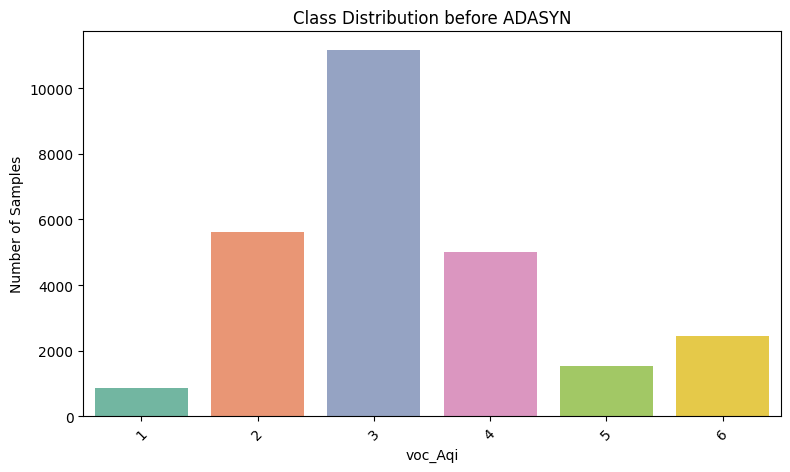

In [227]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
sns.countplot(x=y_train, data=New_data,palette='Set2')
plt.xticks(rotation=45, fontsize=10)
plt.title('Class Distribution before ADASYN')
plt.ylabel('Number of Samples')
plt.show()

In [228]:
y_train.value_counts()

,count
voc_Aqi,
3,11168
2,5629
4,4998
6,2460
5,1534
1,873


In [229]:
from imblearn.over_sampling import ADASYN
from collections import Counter

strategy = {

    6 : 4800,
    5 : 4700,
    1 : 4500 ,

}
ada = ADASYN(sampling_strategy=strategy, random_state=42, n_neighbors=6)

# 3. Fit and resample the data
X_train_resampled, y_train_resampled = ada.fit_resample(X_train, y_train)


/tmp/ipykernel_4977/3650082686.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, data=New_data,palette='Set2')


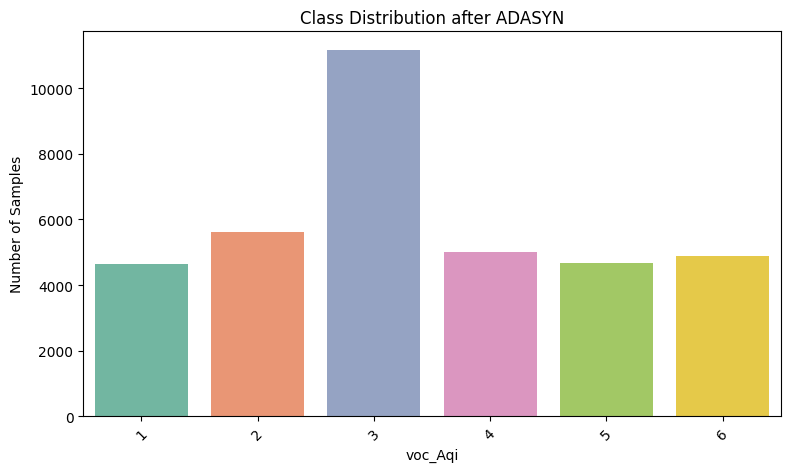

In [230]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
sns.countplot(x=y_train_resampled, data=New_data,palette='Set2')
plt.xticks(rotation=45, fontsize=10)
plt.title('Class Distribution after ADASYN')
plt.ylabel('Number of Samples')
plt.show()

In [231]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train_resampled)


# Transform the test data using the fitted scaler
x_test_scaled = scaler.transform(X_test)


# Scale the validation data using the pre-fitted scaler
X_val_scaled = scaler.transform(X_val)

print("Min-Max scaling applied to x_train_resampled, X_test, and X_val.")

Min-Max scaling applied to x_train_resampled, X_test, and X_val.


In [232]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print('-------------- Random Forest without Scaled Data -------------\n')
print(classification_report(y_test, y_pred))

-------------- Random Forest without Scaled Data -------------

              precision    recall  f1-score   support

           1       0.84      0.95      0.89       218
           2       0.95      0.94      0.94      1635
           3       0.94      0.94      0.94      3279
           4       0.89      0.84      0.87      1512
           5       0.71      0.74      0.73       446
           6       0.91      0.93      0.92       753

    accuracy                           0.91      7843
   macro avg       0.87      0.89      0.88      7843
weighted avg       0.91      0.91      0.91      7843



In [233]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# 3. Configure K-fold cross-validation
# n_splits (k) is set to 5. shuffle=True ensures random distribution of data.
k_folds = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Perform cross-validation and get scores
# 'cv' parameter takes the cross-validation iterator
scores = cross_val_score(model, X_val, y_val, cv=k_folds)

# 5. Print the results
print("Cross Validation Scores:", scores)
print(f"Average CV Score: {np.mean(scores):.4f}")
print("Number of CV Scores used in Average:", len(scores))


Cross Validation Scores: [0.81316348 0.80977683 0.82890542 0.82784272 0.81296493]
Average CV Score: 0.8185
Number of CV Scores used in Average: 5


In [246]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU , Dropout

# Get the number of features for the input layer after preprocessing

input_dim = 5

# Define the neural network model

'''
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)), # Input layer + first hidden layer
    BatchNormalization(), # Batch normalization layer
    Dropout(0.1), # Dropout layer to prevent overfitting
    Dense(64, activation='relu'), # Second hidden layer
    BatchNormalization(), # Batch normalization layer
    Dropout(0.1), # Dropout layer to prevent overfitting

    Dense(32, activation='relu'), # Third hidden layer
    BatchNormalization(), # Batch normalization layer
    Dropout(0.1), # Dropout layer to prevent overfitting
    Dense(6, activation='softmax') # Output layer for 6 classes (0, 1, 2, 3, 4, 5)
])

'''

model = Sequential([
    Dense(256, input_shape=(input_dim,)),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),
    #Dropout(0.2),

    Dense(128),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),
    #Dropout(0.2),

    Dense(64),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),
    #Dropout(0.1),

    Dense(6, activation='softmax')
])

# Compile the model

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_63 (Dense)                │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,870 (175.27 KB)

 Trainable params: 43,974 (171.77 KB)

 Non-trainable params: 896 (3.50 KB)

In [247]:

y_train_adjusted = y_train_resampled - 1
y_val_adjusted = y_val - 1
y_test_adjusted = y_test - 1

In [248]:
history = model.fit(
    X_train_scaled,
    y_train_adjusted,
    epochs=500,
    validation_data=(X_val_scaled, y_val_adjusted),
    batch_size=256
)

Epoch 1/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.4897 - loss: 1.2938 - val_accuracy: 0.4086 - val_loss: 1.6708
Epoch 2/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5996 - loss: 1.0307 - val_accuracy: 0.3608 - val_loss: 1.7292
Epoch 3/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6334 - loss: 0.9416 - val_accuracy: 0.3908 - val_loss: 1.5038
Epoch 4/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6597 - loss: 0.8747 - val_accuracy: 0.5334 - val_loss: 1.1453
Epoch 5/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6710 - loss: 0.8299 - val_accuracy: 0.6504 - val_loss: 0.8593
Epoch 6/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6909 - loss: 0.7868 - val_accuracy: 0.6728 - val_loss: 0.8304
Epoch 7/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7029 - loss: 0.7544 - val_accuracy: 0.6951 - val_loss: 0.7524
Epoch 8/500
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7134 - loss: 0.7318 - val_acc

In [250]:
from tensorflow.keras.utils import to_categorical

# Determine the number of classes (from 0 to 5, so 6 classes total)
num_classes = 6

# Convert y_test_adjusted to one-hot encoded format
y_test_one_hot = to_categorical(y_test_adjusted.values, num_classes=num_classes)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test_adjusted, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.3453
Test Accuracy: 0.8810


In [251]:
import os
import pickle

# Define the filename for the pickle file
filename = 'AQI_model_voc.pkl'

# Save the model to a pickle file
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Neural network model saved to: {filename}")

Neural network model saved to: AQI_model_voc.pkl


# PM2_5 Model to Predict AQI

In [265]:
df_pm2_5 = New_data.drop(columns=['data_voc','data_co2','data_pm2_5','co2_Aqi','voc_Aqi'], axis = 1)
x_pm2_5 = df_pm2_5.drop(columns=['pm2_5_Aqi'])
y_pm2_5 = df_pm2_5['pm2_5_Aqi']

In [266]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(x_pm2_5, y_pm2_5, test_size=0.2, random_state=42)

# Split the full training data into 85% training and 15% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, {y_val.shape}")
print(f"Test data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (26662, 5), (26662,)
Validation data shape: (4706, 5), (4706,)
Test data shape: (7843, 5), (7843,)


/tmp/ipykernel_4977/4221333868.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, data=df_pm2_5,palette='Set2')


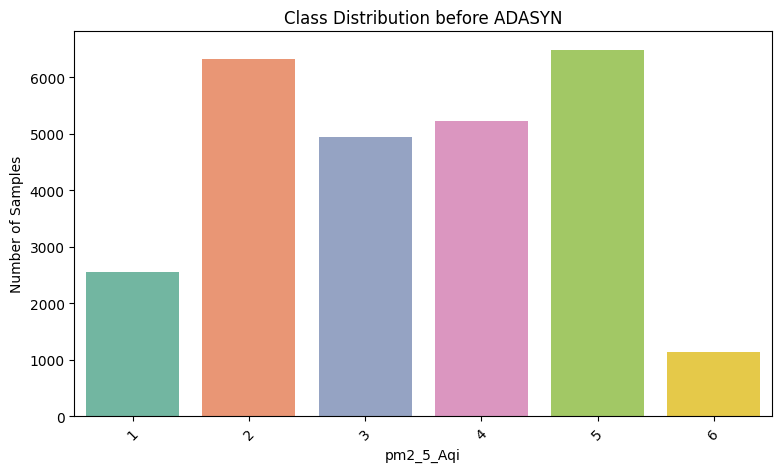

In [267]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
sns.countplot(x=y_train, data=df_pm2_5,palette='Set2')
plt.xticks(rotation=45, fontsize=10)
plt.title('Class Distribution before ADASYN')
plt.ylabel('Number of Samples')
plt.show()

In [268]:
y_train.value_counts()

,count
pm2_5_Aqi,
5,6485
2,6325
4,5216
3,4940
1,2559
6,1137


In [272]:
from imblearn.over_sampling import ADASYN
from collections import Counter

strategy = {

    1 : 5000,
    6 : 5000,

}
ada = ADASYN(sampling_strategy=strategy, random_state=42, n_neighbors=5)

# 3. Fit and resample the data
X_train_resampled, y_train_resampled = ada.fit_resample(X_train, y_train)

/tmp/ipykernel_4977/220224907.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, data=df_pm2_5,palette='Set2')


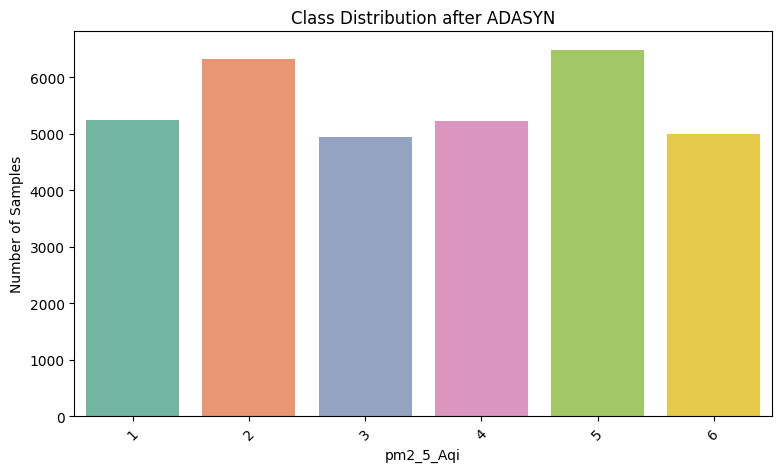

In [273]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
sns.countplot(x=y_train_resampled, data=df_pm2_5,palette='Set2')
plt.xticks(rotation=45, fontsize=10)
plt.title('Class Distribution after ADASYN')
plt.ylabel('Number of Samples')
plt.show()

In [274]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train_resampled)


# Transform the test data using the fitted scaler
x_test_scaled = scaler.transform(X_test)


# Scale the validation data using the pre-fitted scaler
X_val_scaled = scaler.transform(X_val)

print("Min-Max scaling applied to x_train_resampled, X_test, and X_val.")

Min-Max scaling applied to x_train_resampled, X_test, and X_val.


In [275]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print('-------------- Random Forest without Scaled Data -------------\n')
print(classification_report(y_test, y_pred))

-------------- Random Forest without Scaled Data -------------

              precision    recall  f1-score   support

           1       0.95      0.97      0.96       780
           2       0.94      0.93      0.94      1781
           3       0.90      0.88      0.89      1414
           4       0.92      0.91      0.91      1566
           5       0.96      0.95      0.95      1973
           6       0.79      0.92      0.85       329

    accuracy                           0.93      7843
   macro avg       0.91      0.93      0.92      7843
weighted avg       0.93      0.93      0.93      7843



In [276]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# 3. Configure K-fold cross-validation
# n_splits (k) is set to 5. shuffle=True ensures random distribution of data.
k_folds = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Perform cross-validation and get scores
# 'cv' parameter takes the cross-validation iterator
scores = cross_val_score(model, X_val, y_val, cv=k_folds)

# 5. Print the results
print("Cross Validation Scores:", scores)
print(f"Average CV Score: {np.mean(scores):.4f}")
print("Number of CV Scores used in Average:", len(scores))


Cross Validation Scores: [0.86305732 0.84803401 0.87672689 0.8597237  0.8607864 ]
Average CV Score: 0.8617
Number of CV Scores used in Average: 5


In [284]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU , Dropout

# Get the number of features for the input layer after preprocessing

input_dim = 5

# Define the neural network model

'''
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)), # Input layer + first hidden layer
    BatchNormalization(), # Batch normalization layer
    Dropout(0.1), # Dropout layer to prevent overfitting
    Dense(64, activation='relu'), # Second hidden layer
    BatchNormalization(), # Batch normalization layer
    Dropout(0.1), # Dropout layer to prevent overfitting

    Dense(32, activation='relu'), # Third hidden layer
    BatchNormalization(), # Batch normalization layer
    Dropout(0.1), # Dropout layer to prevent overfitting
    Dense(6, activation='softmax') # Output layer for 6 classes (0, 1, 2, 3, 4, 5)
])

'''

model = Sequential([
    Dense(256, input_shape=(input_dim,)),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),

    Dense(128),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),

    Dense(64),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),

    Dense(6, activation='softmax')
])

# Compile the model

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_75 (Dense)                │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,870 (175.27 KB)

 Trainable params: 43,974 (171.77 KB)

 Non-trainable params: 896 (3.50 KB)

In [285]:
y_train_adjusted = y_train_resampled - 1
y_val_adjusted = y_val - 1
y_test_adjusted = y_test - 1

In [286]:
history = model.fit(
    X_train_scaled,
    y_train_adjusted,
    epochs=500,
    validation_data=(X_val_scaled, y_val_adjusted),
    batch_size=256
)

Epoch 1/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5457 - loss: 1.2087 - val_accuracy: 0.1902 - val_loss: 1.8328
Epoch 2/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6603 - loss: 0.9049 - val_accuracy: 0.1955 - val_loss: 1.9025
Epoch 3/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7041 - loss: 0.7942 - val_accuracy: 0.2731 - val_loss: 1.8430
Epoch 4/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7288 - loss: 0.7247 - val_accuracy: 0.4435 - val_loss: 1.3713
Epoch 5/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7508 - loss: 0.6655 - val_accuracy: 0.6324 - val_loss: 0.9123
Epoch 6/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7654 - loss: 0.6274 - val_accuracy: 0.7382 - val_loss: 0.6892
Epoch 7/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7770 - loss: 0.5968 - val_accuracy: 0.7291 - val_loss: 0.7055
Epoch 8/500
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7869 - loss: 0.5738 - val_ac

In [287]:
from tensorflow.keras.utils import to_categorical

# Determine the number of classes (from 0 to 5, so 6 classes total)
num_classes = 6

# Convert y_test_adjusted to one-hot encoded format
y_test_one_hot = to_categorical(y_test_adjusted.values, num_classes=num_classes)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test_adjusted, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2404
Test Accuracy: 0.9118


In [288]:
import os
import pickle

# Define the filename for the pickle file
filename = 'AQI_model_pm2_5.pkl'

# Save the model to a pickle file
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Neural network model saved to: {filename}")

Neural network model saved to: AQI_model_pm2_5.pkl


# CO2 Model to Predict AQI

In [289]:
df_co2 = New_data.drop(columns=['data_voc','data_co2','data_pm2_5','pm2_5_Aqi','voc_Aqi'], axis = 1)
x_co2 = df_co2.drop(columns=['co2_Aqi'])
y_co2 = df_co2['co2_Aqi']

In [291]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(x_co2, y_co2, test_size=0.2, random_state=42)

# Split the full training data into 85% training and 15% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, {y_val.shape}")
print(f"Test data shape: {X_test.shape}, {y_test.shape}")

Training data shape: (26662, 5), (26662,)
Validation data shape: (4706, 5), (4706,)
Test data shape: (7843, 5), (7843,)


/tmp/ipykernel_4977/3226384273.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, data=df_co2,palette='Set2')


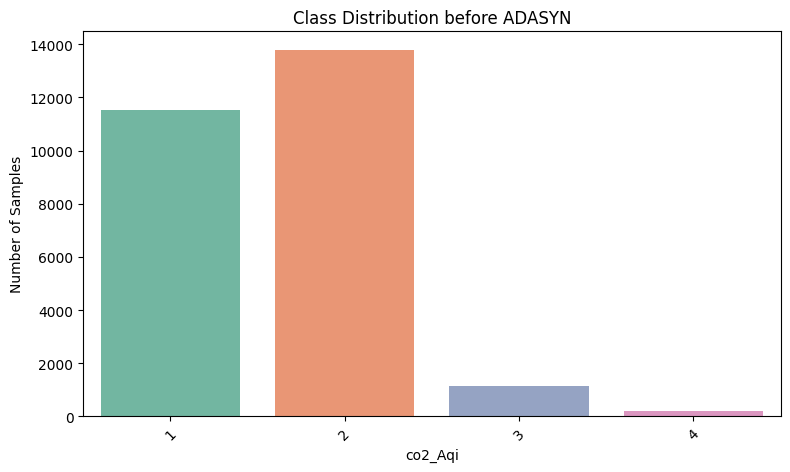

In [292]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
sns.countplot(x=y_train, data=df_co2,palette='Set2')
plt.xticks(rotation=45, fontsize=10)
plt.title('Class Distribution before ADASYN')
plt.ylabel('Number of Samples')
plt.show()

In [293]:
y_train.value_counts()

,count
co2_Aqi,
2,13795
1,11527
3,1154
4,186


In [296]:
from imblearn.over_sampling import ADASYN
from collections import Counter

strategy = {

    4 : 7000,
    3 : 7500,

}
ada = ADASYN(sampling_strategy=strategy, random_state=42, n_neighbors=5)

# 3. Fit and resample the data
X_train_resampled, y_train_resampled = ada.fit_resample(X_train, y_train)

/tmp/ipykernel_4977/85562240.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, data=df_co2,palette='Set2')


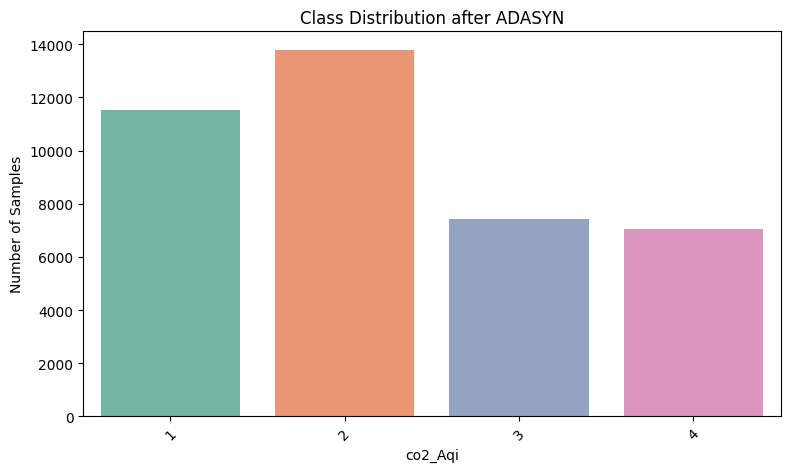

In [297]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
sns.countplot(x=y_train_resampled, data=df_co2,palette='Set2')
plt.xticks(rotation=45, fontsize=10)
plt.title('Class Distribution after ADASYN')
plt.ylabel('Number of Samples')
plt.show()

In [298]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train_resampled)


# Transform the test data using the fitted scaler
x_test_scaled = scaler.transform(X_test)


# Scale the validation data using the pre-fitted scaler
X_val_scaled = scaler.transform(X_val)

print("Min-Max scaling applied to x_train_resampled, X_test, and X_val.")

Min-Max scaling applied to x_train_resampled, X_test, and X_val.


In [299]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print('-------------- Random Forest without Scaled Data -------------\n')
print(classification_report(y_test, y_pred))

-------------- Random Forest without Scaled Data -------------

              precision    recall  f1-score   support

           1       0.98      0.99      0.98      3394
           2       0.98      0.97      0.97      4026
           3       0.77      0.86      0.82       352
           4       0.76      0.79      0.77        71

    accuracy                           0.97      7843
   macro avg       0.87      0.90      0.89      7843
weighted avg       0.97      0.97      0.97      7843



In [300]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# 3. Configure K-fold cross-validation
# n_splits (k) is set to 5. shuffle=True ensures random distribution of data.
k_folds = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Perform cross-validation and get scores
# 'cv' parameter takes the cross-validation iterator
scores = cross_val_score(model, X_val, y_val, cv=k_folds)

# 5. Print the results
print("Cross Validation Scores:", scores)
print(f"Average CV Score: {np.mean(scores):.4f}")
print("Number of CV Scores used in Average:", len(scores))


Cross Validation Scores: [0.89808917 0.90435707 0.91498406 0.91073326 0.92029756]
Average CV Score: 0.9097
Number of CV Scores used in Average: 5


In [301]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, LeakyReLU , Dropout

# Get the number of features for the input layer after preprocessing

input_dim = 5

# Define the neural network model

'''
model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)), # Input layer + first hidden layer
    BatchNormalization(), # Batch normalization layer
    Dropout(0.1), # Dropout layer to prevent overfitting
    Dense(64, activation='relu'), # Second hidden layer
    BatchNormalization(), # Batch normalization layer
    Dropout(0.1), # Dropout layer to prevent overfitting

    Dense(32, activation='relu'), # Third hidden layer
    BatchNormalization(), # Batch normalization layer
    Dropout(0.1), # Dropout layer to prevent overfitting
    Dense(6, activation='softmax') # Output layer for 6 classes (0, 1, 2, 3, 4, 5)
])

'''

model = Sequential([
    Dense(256, input_shape=(input_dim,)),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),

    Dense(128),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),

    Dense(64),
    LeakyReLU(alpha=0.01),
    BatchNormalization(),

    Dense(6, activation='softmax')
])

# Compile the model

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_79 (Dense)                │ (None, 256)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,870 (175.27 KB)

 Trainable params: 43,974 (171.77 KB)

 Non-trainable params: 896 (3.50 KB)

In [302]:
y_train_adjusted = y_train_resampled - 1
y_val_adjusted = y_val - 1
y_test_adjusted = y_test - 1

In [303]:
history = model.fit(
    X_train_scaled,
    y_train_adjusted,
    epochs=500,
    validation_data=(X_val_scaled, y_val_adjusted),
    batch_size=256
)

Epoch 1/500
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7126 - loss: 0.8176 - val_accuracy: 0.4271 - val_loss: 1.3789
Epoch 2/500
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7847 - loss: 0.5596 - val_accuracy: 0.5419 - val_loss: 1.1637
Epoch 3/500
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8021 - loss: 0.4972 - val_accuracy: 0.6494 - val_loss: 0.7923
Epoch 4/500
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8175 - loss: 0.4567 - val_accuracy: 0.7612 - val_loss: 0.5411
Epoch 5/500
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8303 - loss: 0.4294 - val_accuracy: 0.8364 - val_loss: 0.4113
Epoch 6/500
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8388 - loss: 0.4078 - val_accuracy: 0.8315 - val_loss: 0.4290
Epoch 7/500
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8462 - loss: 0.3880 - val_accuracy: 0.8398 - val_loss: 0.4182
Epoch 8/500
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8515 - loss: 0.3751 - val_accu

In [304]:
from tensorflow.keras.utils import to_categorical

# Determine the number of classes (from 0 to 5, so 6 classes total)
num_classes = 6

# Convert y_test_adjusted to one-hot encoded format
y_test_one_hot = to_categorical(y_test_adjusted.values, num_classes=num_classes)

test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test_adjusted, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1346
Test Accuracy: 0.9565


In [305]:
import os
import pickle

# Define the filename for the pickle file
filename = 'AQI_model_co2.pkl'

# Save the model to a pickle file
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Neural network model saved to: {filename}")

Neural network model saved to: AQI_model_co2.pkl


#

#